# PCA for Mixed Properties in Malaysia Dataset

In [321]:
import pandas as pd 
import numpy as np
import missingno as msno 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix
from sklearn.ensemble import RandomForestRegressor

In [322]:
train_file_path = "2026 NAPIC - Open Transaction Data  (270226) (1).csv" 
df = pd.read_csv(train_file_path, encoding='utf-16', sep='\t')
print("Full train dataset shape is {}".format(df.shape))

Full train dataset shape is (481478, 14)


In [323]:
df.head(5)

,Property Type,District,Mukim,Scheme Name/Area,Road Name,"Month, Year of Transaction Date",Tenure,Land/Parcel Area,Unit,Main Floor Area,Unit,Unit Level,Transaction Price,Unnamed: 13
0,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Bdr Masjid Tanah,TMN BUKIT INDAH FASA 2,JLN BUKIT INDAH 6,March 2024,Freehold,374.00,sq.m,106,sq.m,,"RM470,000.00",NaN
1,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN BELIMBING HARMONI,JLN BELIMBING HARMONI,May 2023,Leasehold,234.00,sq.m,67,sq.m,,"RM483,000.00",NaN
2,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN VISTA BELIMBING,JALAN DURIAN TUNGGAL-ALOR GAJAH,April 2021,Freehold,268.00,sq.m,118,sq.m,,"RM359,000.00",NaN
3,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN VISTA BELIMBING,JALAN DURIAN TUNGGAL-ALOR GAJAH,April 2021,Freehold,268.00,sq.m,118,sq.m,,"RM435,000.00",NaN
4,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN VISTA BELIMBING,JALAN DURIAN TUNGGAL-ALOR GAJAH,April 2021,Freehold,297.00,sq.m,118,sq.m,,"RM373,000.00",NaN


In [324]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 481478 entries, 0 to 481477
Data columns (total 14 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   Property Type                    481478 non-null  str    
 1   District                         481478 non-null  str    
 2   Mukim                            481478 non-null  str    
 3   Scheme Name/Area                 481478 non-null  str    
 4   Road Name                        481478 non-null  str    
 5   Month, Year of Transaction Date  481478 non-null  str    
 6   Tenure                           481478 non-null  str    
 7   Land/Parcel Area                 481478 non-null  str    
 8   Unit                             481478 non-null  str    
 9   Main Floor Area                  481478 non-null  str    
 10  Unit                             481478 non-null  str    
 11  Unit Level                       481478 non-null  str    
 12  Transaction P

In [325]:
# inspect column name, view any whitespace
print("\nExisting column :\n " + f"{df.columns.tolist()}") 


Existing column :
 ['Property Type', 'District', 'Mukim', 'Scheme Name/Area', 'Road Name', 'Month, Year of Transaction Date', 'Tenure', 'Land/Parcel Area', 'Unit', 'Main Floor Area', 'Unit        ', 'Unit Level', 'Transaction Price  ', 'Unnamed: 13']


In [326]:
# remove leading and trailing whitespace
df.columns = df.columns.str.strip() 
print("\nColumn after remove leading & trailing whitespace :\n " + f"{df.columns.tolist()}") 

# remove the entire column only if all values are NaN and print the output after removed NaN column
df = df.dropna(axis=1, how='all') 
print("\nResult after remove NaN column :\n"+ f"{df.columns.tolist()}")

# dropping column that we want to ignore
df = df.drop(columns=['Unit','Unit Level']) 
print("\nResult after remove ignored column :\n"+ f"{df.columns.tolist()}")

# finding unique value for Transaction Price
print(df['Transaction Price'].unique(),'\n')
print(df['Transaction Price'][df['Transaction Price'] == ''],'\n')  # find empty strings

# Clean and convert 'Transaction Price' to numeric
df['Transaction Price'] = df['Transaction Price'].str.replace('RM', '', regex=False)
df['Transaction Price'] = df['Transaction Price'].str.replace(',', '', regex=False).astype(float)

# finding unique value for Main Floor Area
print(df['Main Floor Area'].unique(),'\n')
print(df['Main Floor Area'][df['Main Floor Area'] == ''],'\n')  # find empty strings

# Clean and convert 'Main Floor Area' to numeric
df['Main Floor Area'] = df['Main Floor Area'].str.replace('-', '', regex=False)
df['Main Floor Area'] = df['Main Floor Area'].str.replace(',', '', regex=False).replace('', np.nan).astype(float)

# finding unique value for Land/Parcel Area
print(df['Land/Parcel Area'].unique(),'\n')
print(df['Land/Parcel Area'][df['Land/Parcel Area'] == ''],'\n')  # find empty strings

# Clean and convert 'Land/Parcel Area' to numeric
df['Land/Parcel Area'] = df['Land/Parcel Area'].str.replace('-', '', regex=False)
df['Land/Parcel Area'] = df['Land/Parcel Area'].str.replace(',', '', regex=False).replace('', np.nan).astype(float)


Column after remove leading & trailing whitespace :
 ['Property Type', 'District', 'Mukim', 'Scheme Name/Area', 'Road Name', 'Month, Year of Transaction Date', 'Tenure', 'Land/Parcel Area', 'Unit', 'Main Floor Area', 'Unit', 'Unit Level', 'Transaction Price', 'Unnamed: 13']

Result after remove NaN column :
['Property Type', 'District', 'Mukim', 'Scheme Name/Area', 'Road Name', 'Month, Year of Transaction Date', 'Tenure', 'Land/Parcel Area', 'Unit', 'Main Floor Area', 'Unit', 'Unit Level', 'Transaction Price']

Result after remove ignored column :
['Property Type', 'District', 'Mukim', 'Scheme Name/Area', 'Road Name', 'Month, Year of Transaction Date', 'Tenure', 'Land/Parcel Area', 'Main Floor Area', 'Transaction Price']
<StringArray>
[  'RM470,000.00',   'RM483,000.00',   'RM359,000.00',   'RM435,000.00',
   'RM373,000.00',   'RM658,000.00',   'RM458,000.00',   'RM460,000.00',
   'RM494,000.00',   'RM530,000.00',
 ...
 'RM3,372,000.00', 'RM2,878,000.00', 'RM4,108,000.00', 'RM3,566,00

<Axes: >

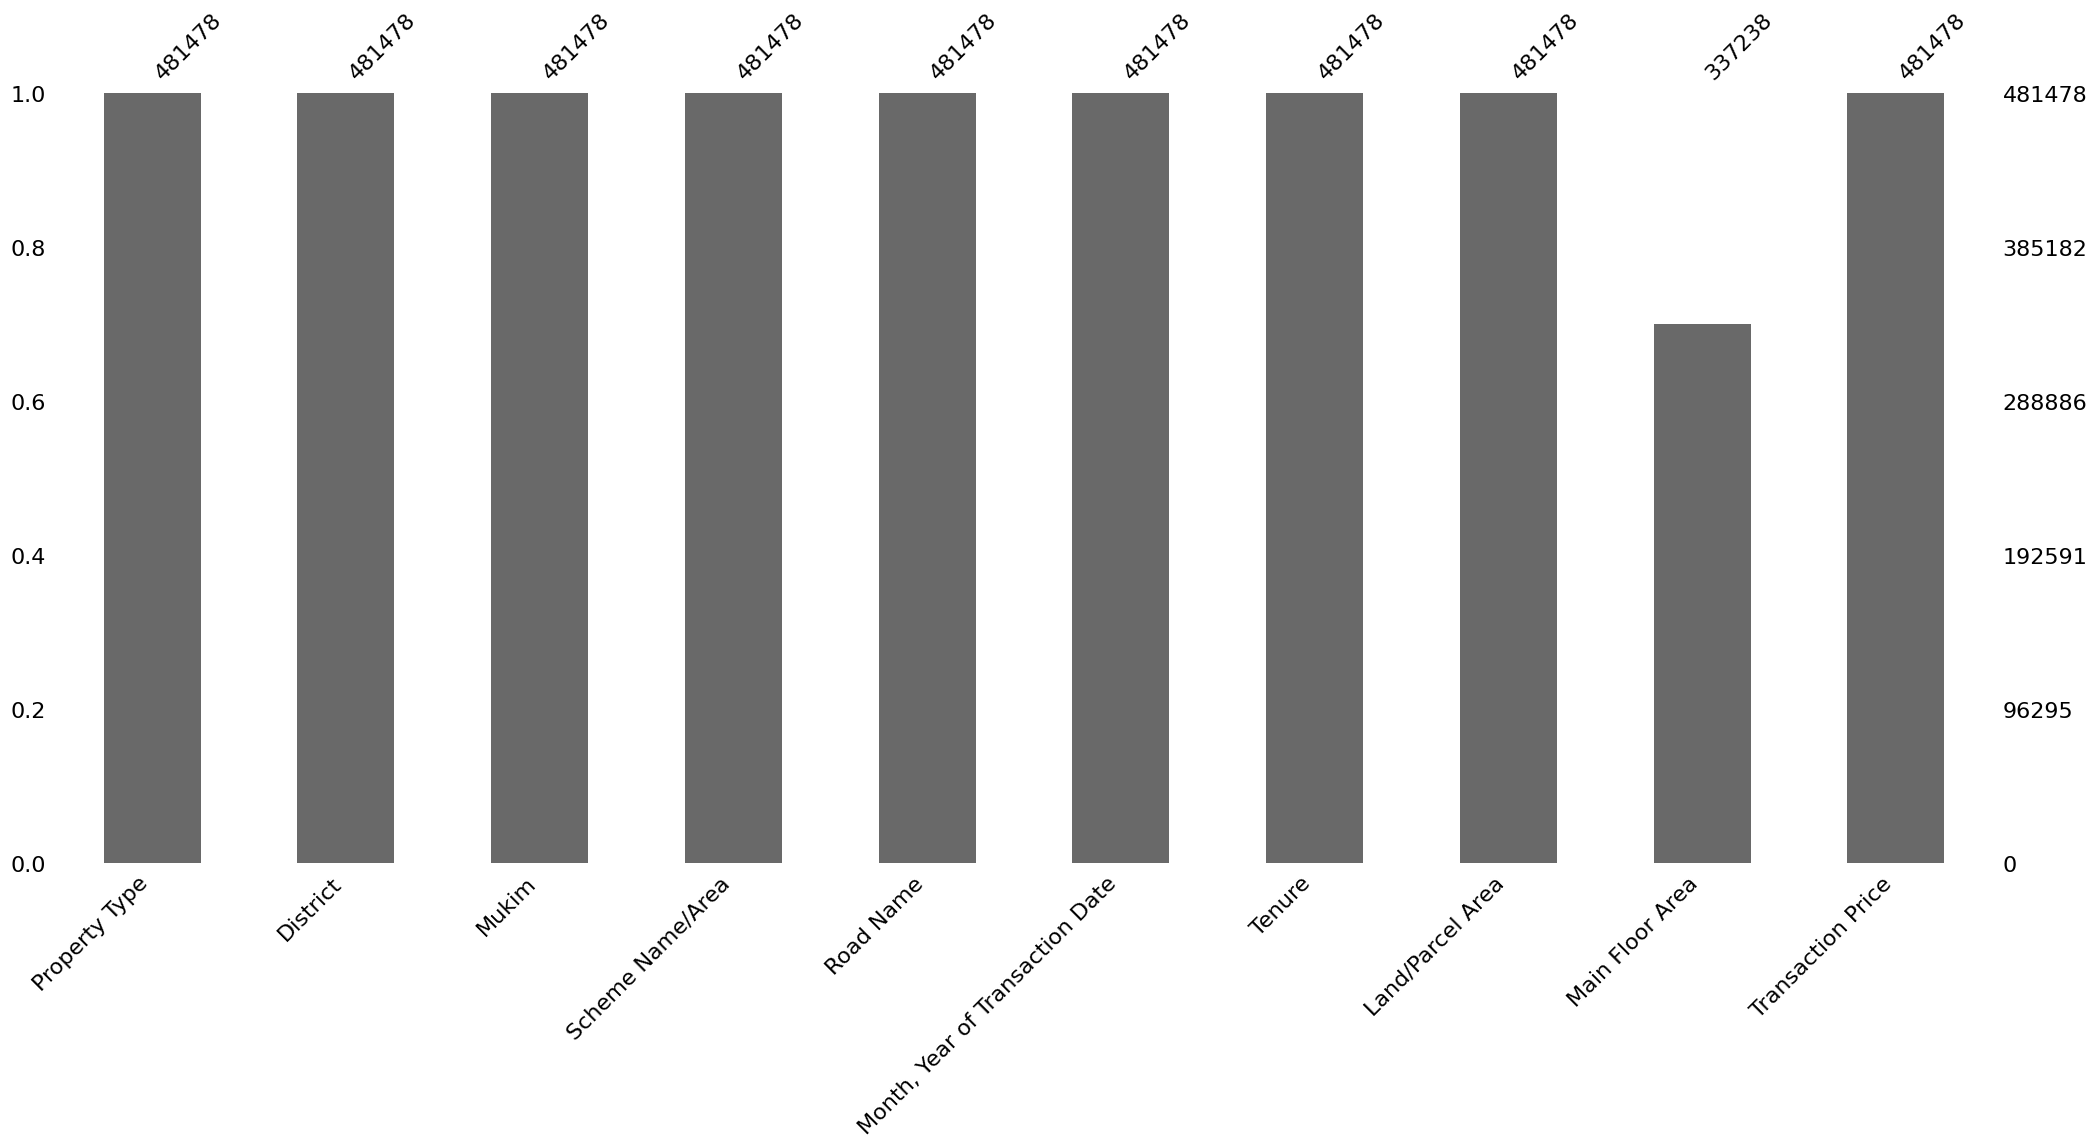

In [327]:
msno.bar(df)

In [328]:
X=df[['District', 'Mukim', 'Scheme Name/Area', 'Road Name', 'Month, Year of Transaction Date', 'Tenure', 'Land/Parcel Area', 'Main Floor Area']]
y=df['Transaction Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [329]:

# Find ALL categorical columns
object_cols = X.select_dtypes(include=['object', 'string']).columns

# Check how many unique categories per column
cardinality = X[object_cols].nunique().sort_values(ascending=False)
cardinality.head(20)

Road Name                          134037
Scheme Name/Area                    28550
Mukim                                1395
District                              130
Month, Year of Transaction Date        57
Tenure                                  2
dtype: int64

In [330]:

low_card_cols = [c for c in object_cols if X[c].nunique() < 60]
high_card_cols = [c for c in object_cols if X[c].nunique() >= 60]

print("Low-cardinality categorical columns:", len(low_card_cols))
print("High-cardinality categorical columns:", len(high_card_cols))


Low-cardinality categorical columns: 2
High-cardinality categorical columns: 4


In [331]:
# numeric columns (everything that is not in low_card_cols)
num_X = X.drop(object_cols, axis=1)   # drop all categoricals
# OR: num_X = X.select_dtypes(include=['int64', 'float64'])

OH_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit on low-cardinality columns only
OH_cols = pd.DataFrame(OH_encoder.fit_transform(X[low_card_cols]),index=X.index)

# Concatenate back
OH_X = pd.concat([num_X, OH_cols], axis=1)

# Make sure column names are strings
OH_X.columns = OH_X.columns.astype(str)

print("Final shape:", OH_X.shape)


Final shape: (481478, 61)


In [332]:

print("Number of unique labels in y:", len(np.unique(y)))
print("Example labels:", list(np.unique(y)[:10]))

Number of unique labels in y: 4546
Example labels: [np.float64(5000.0), np.float64(11000.0), np.float64(12000.0), np.float64(13000.0), np.float64(14000.0), np.float64(15000.0), np.float64(16000.0), np.float64(17000.0), np.float64(18000.0), np.float64(19000.0)]


Applying RandomForestRegressor algorithm

In [ ]:
OH_X = OH_X.fillna(0)

X_train, X_test, y_train, y_test = train_test_split(OH_X, y, test_size=0.3, random_state=42)

model = RandomForestRegressor(n_estimators=300,random_state=42,n_jobs=-1)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("NO PCA MSE:", mean_squared_error(y_test, y_pred))
print("NO PCA R²:", r2_score(y_test, y_pred))


In [ ]:
# Check feature importance
importances = pd.Series(model.feature_importances_, index=OH_X.columns)
print(importances.sort_values(ascending=False))

Main Floor Area     0.588616
Land/Parcel Area    0.397551
0                   0.007096
1                   0.006738
dtype: float64


Applying PCA algorithm:

In [ ]:
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

model = RandomForestRegressor(n_estimators=100,random_state=42,n_jobs=-1)


model.fit(X_train_pca, y_train)

y_pred = model.predict(X_test_pca)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

MSE: 1891879506755.7644
R²: -0.1722600269269643


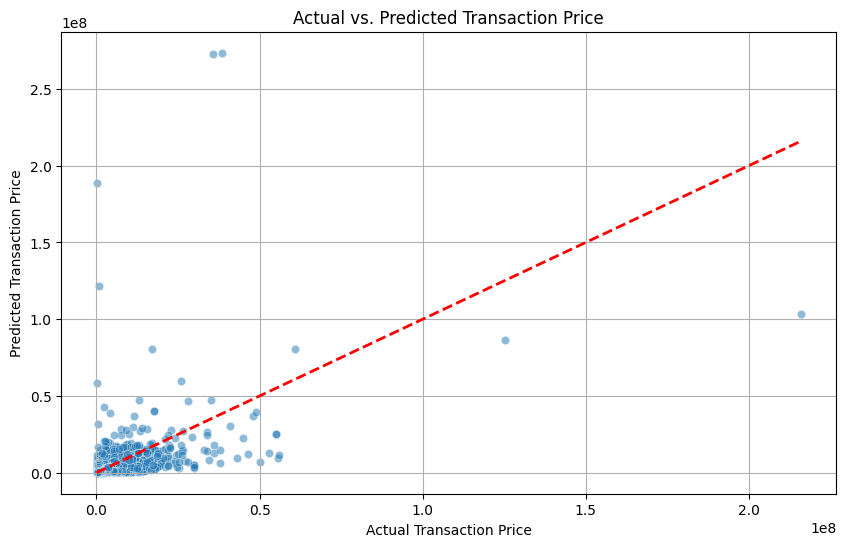

In [ ]:
# Evaluating with Scatter Plot

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Transaction Price')
plt.ylabel('Predicted Transaction Price')
plt.title('Actual vs. Predicted Transaction Price')
plt.grid(True)
plt.show()